# 🌍 Travel Destination Recommendation — Logistic Regression vs Random Forest
**Objective:** Predict the best `DestinationName` using Human-Implemented (Logistic Regression) vs AI-Recommended (Random Forest) models.

This notebook implements a **supervised multi-class classification** pipeline following strict academic methodology.


## Data Preprocessing

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, top_k_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.pipeline import Pipeline
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')

# Load raw data
df_users = pd.read_csv('/home/erxanitea/Documents/Trained Model/ml-training/dataset/raw/Final_Updated_Expanded_Users.csv')
df_history = pd.read_csv('/home/erxanitea/Documents/Trained Model/ml-training/dataset/raw/Final_Updated_Expanded_UserHistory.csv')
df_destinations = pd.read_csv('/home/erxanitea/Documents/Trained Model/ml-training/dataset/raw/Expanded_Destinations.csv')
df_reviews = pd.read_csv('/home/erxanitea/Documents/Trained Model/ml-training/dataset/raw/Final_Updated_Expanded_Reviews.csv')

print('Datasets loaded successfully')

Datasets loaded successfully


---
## 1. Data Quality Assessment

In [125]:
df_destinations.rename(columns={'Name': 'DestinationName'}, inplace=True)
df = pd.merge(pd.merge(pd.merge(df_history, df_users, on='UserID'), df_destinations, on='DestinationID'), df_reviews, on=['UserID', 'DestinationID'], how='left')

print('Datasets merged successfully.')


print('\n' + '=' * 60)
print('MERGED DATASET (Users + History + Destinations + Reviews)')
print('=' * 60)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
display(df.describe(include='all'))
print('\nMissing Values (merged):\n', df.isnull().sum())
print('\nFirst 10 rows of merged dataset:')
display(df.head(10))

Datasets merged successfully.

MERGED DATASET (Users + History + Destinations + Reviews)
Shape: (1510, 21)
Columns: ['HistoryID', 'UserID', 'DestinationID', 'VisitDate', 'ExperienceRating', 'Name', 'Email', 'Preferences', 'Gender', 'NumberOfAdults', 'NumberOfChildren', 'Age', 'Budget', 'DestinationName', 'State', 'Type', 'Popularity', 'BestTimeToVisit', 'ReviewID', 'Rating', 'ReviewText']


,HistoryID,UserID,DestinationID,VisitDate,ExperienceRating,Name,Email,Preferences,Gender,NumberOfAdults,...,Age,Budget,DestinationName,State,Type,Popularity,BestTimeToVisit,ReviewID,Rating,ReviewText
count,1510.000000,1510.000000,1510.000000,1510,1510.000000,1510,1510,1510,1510,1510.000000,...,1510.000000,1510,1510,1510,1510,1510.000000,1510,0.0,0.0,0
unique,NaN,NaN,NaN,603,NaN,20,20,5,2,NaN,...,NaN,3,25,17,16,NaN,5,NaN,NaN,0
top,NaN,NaN,NaN,2023-10-02,NaN,Aanya,aanya@example.com,Nature & Adventure,Male,NaN,...,NaN,Medium,Munnar,Kerala,Historical City,NaN,Apr-Jun,NaN,NaN,NaN
freq,NaN,NaN,NaN,10,NaN,92,92,326,762,NaN,...,NaN,637,110,200,283,NaN,398,NaN,NaN,NaN
mean,755.500000,499.353642,12.993377,NaN,4.141722,NaN,NaN,NaN,NaN,1.504636,...,34.935762,NaN,NaN,NaN,NaN,8.438000,NaN,NaN,NaN,NaN
std,436.043767,286.942601,7.053048,NaN,0.994908,NaN,NaN,NaN,NaN,0.500144,...,10.963545,NaN,NaN,NaN,NaN,0.593015,NaN,NaN,NaN,NaN
min,1.000000,1.000000,1.000000,NaN,1.000000,NaN,NaN,NaN,NaN,1.000000,...,18.000000,NaN,NaN,NaN,NaN,7.560000,NaN,NaN,NaN,NaN
25%,378.250000,251.000000,7.000000,NaN,4.000000,NaN,NaN,NaN,NaN,1.000000,...,27.000000,NaN,NaN,NaN,NaN,7.900000,NaN,NaN,NaN,NaN
50%,755.500000,501.500000,13.000000,NaN,4.000000,NaN,NaN,NaN,NaN,2.000000,...,35.000000,NaN,NaN,NaN,NaN,8.650000,NaN,NaN,NaN,NaN
75%,1132.750000,741.000000,19.000000,NaN,5.000000,NaN,NaN,NaN,NaN,2.000000,...,42.000000,NaN,NaN,NaN,NaN,8.900000,NaN,NaN,NaN,NaN



Missing Values (merged):
 HistoryID              0
UserID                 0
DestinationID          0
VisitDate              0
ExperienceRating       0
Name                   0
Email                  0
Preferences            0
Gender                 0
NumberOfAdults         0
NumberOfChildren       0
Age                    0
Budget                 0
DestinationName        0
State                  0
Type                   0
Popularity             0
BestTimeToVisit        0
ReviewID            1510
Rating              1510
ReviewText          1510
dtype: int64

First 10 rows of merged dataset:


,HistoryID,UserID,DestinationID,VisitDate,ExperienceRating,Name,Email,Preferences,Gender,NumberOfAdults,...,Age,Budget,DestinationName,State,Type,Popularity,BestTimeToVisit,ReviewID,Rating,ReviewText
0,1,1,4,2023-02-28,4,Kavya,kavya@example.com,Beaches & Relaxation,Female,1,...,40,Low,Pondicherry,Pondicherry,Coastal City,8.85,Apr-Jun,NaN,NaN,NaN
1,2,1,22,2024-05-15,3,Kavya,kavya@example.com,Beaches & Relaxation,Female,1,...,40,Low,Dharamshala,Himachal Pradesh,Mountain Monasteries,9.16,Apr-Jun,NaN,NaN,NaN
2,3,2,15,2024-06-07,4,Rohan,rohan@example.com,Nature & Adventure,Male,2,...,33,Low,Jim Corbett,Uttarakhand,National Park,9.41,Nov-Mar,NaN,NaN,NaN
3,4,2,12,2023-11-21,5,Rohan,rohan@example.com,Nature & Adventure,Male,2,...,33,Low,Rishikesh,Uttarakhand,Mountain/River,9.02,Nov-Feb,NaN,NaN,NaN
4,5,3,19,2023-03-18,4,Kavya,kavya@example.com,Cultural & Food,Female,2,...,42,Medium,Hyderabad,Telangana,Metropolis,8.96,Apr-Jun,NaN,NaN,NaN
5,6,3,18,2023-07-09,5,Kavya,kavya@example.com,Cultural & Food,Female,2,...,42,Medium,Lucknow,Uttar Pradesh,Historical City,8.71,Oct-Mar,NaN,NaN,NaN
6,7,4,17,2023-01-08,3,Anika,anika@example.com,Cultural & Food,Female,1,...,53,Medium,Amritsar,Punjab,Historical City,7.69,Nov-Mar,NaN,NaN,NaN
7,8,4,18,2023-07-09,4,Anika,anika@example.com,Cultural & Food,Female,1,...,53,Medium,Lucknow,Uttar Pradesh,Historical City,8.71,Oct-Mar,NaN,NaN,NaN
8,9,5,5,2024-10-23,4,Tanvi,tanvi@example.com,Beaches & Relaxation,Female,2,...,32,Low,Varkala,Kerala,Cliff Beach,7.67,Sep-Mar,NaN,NaN,NaN
9,10,6,6,2024-08-13,5,Karan,karan@example.com,City & Historical,Male,2,...,32,High,Jaipur,Rajasthan,Historical City,7.56,Oct-Mar,NaN,NaN,NaN


## 2. Basic Feature Engineering

In [126]:
df['VisitDate'] = pd.to_datetime(df['VisitDate'])
df['TravelMonth'] = df['VisitDate'].dt.month
for p in ['Relaxation', 'Adventure', 'Culture', 'Spiritual']:
    df[f'Pref_{p}'] = df['Preferences'].apply(lambda x: 1 if p in str(x) else 0)

print('Basic feature engineering complete.')

Basic feature engineering complete.


In [127]:
# Calculate average rating per destination
dest_ratings = df_reviews.groupby('DestinationID')['Rating'].agg(['mean', 'count']).reset_index()
dest_ratings.columns = ['DestinationID', 'Avg_Dest_Rating', 'Review_Count']

# Merge with main dataframe
df = pd.merge(df, dest_ratings, on='DestinationID', how='left')

# Fill missing values
df['Avg_Dest_Rating'] = df['Avg_Dest_Rating'].fillna(df['Avg_Dest_Rating'].mean())
df['Review_Count'] = df['Review_Count'].fillna(0)

# Enhanced feature engineering
df['VisitDate'] = pd.to_datetime(df['VisitDate'])
df['TravelMonth'] = df['VisitDate'].dt.month
df['TravelSeason'] = pd.cut(df['TravelMonth'], bins=[0, 3, 6, 9, 12], labels=['Winter', 'Spring', 'Summer', 'Fall'])

# User preference scores (how well destination matches user preferences)
preference_mapping = {
    'Relaxation': ['Beach', 'Coastal City', 'Hill Station'],
    'Adventure': ['Island', 'Hill Station', 'National Park'],
    'Culture': ['Historical', 'Temple', 'Fort'],
    'Spiritual': ['Temple', 'Ashram', 'Pilgrimage']
}

def calculate_preference_match(row):
    user_prefs = str(row['Preferences']).lower()
    dest_type = str(row['Type']).lower()
    score = 0
    for pref, types in preference_mapping.items():
        if pref.lower() in user_prefs:
            if any(t.lower() in dest_type for t in types):
                score += 1
    return score

df['Preference_Match_Score'] = df.apply(calculate_preference_match, axis=1)

# Age group categorization
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 100], labels=['Young', 'Adult', 'Middle', 'Senior', 'Elder'])

# Family size
df['Family_Size'] = df['NumberOfAdults'] + df['NumberOfChildren']
df['Has_Children'] = (df['NumberOfChildren'] > 0).astype(int)

# Budget compatibility score
budget_scores = {'Low': 1, 'Medium': 2, 'High': 3}
df['Budget_Score'] = df['Budget'].map(budget_scores)

# Seasonal popularity match
seasonal_destinations = {
    'Winter': ['Hill Station', 'Temple'],
    'Spring': ['Beach', 'Coastal City'],
    'Summer': ['Hill Station', 'Island'],
    'Fall': ['Historical', 'Temple']
}

def seasonal_match(row):
    season = row['TravelSeason']
    dest_type = str(row['Type'])
    if season in seasonal_destinations:
        return 1 if dest_type in seasonal_destinations[season] else 0
    return 0

df['Seasonal_Match'] = df.apply(seasonal_match, axis=1)

print('Enhanced feature engineering complete.')
print(f'New features added: {["Avg_Dest_Rating", "Review_Count", "TravelSeason", "Preference_Match_Score", "Age_Group", "Family_Size", "Has_Children", "Budget_Score", "Seasonal_Match"]}')

Enhanced feature engineering complete.
New features added: ['Avg_Dest_Rating', 'Review_Count', 'TravelSeason', 'Preference_Match_Score', 'Age_Group', 'Family_Size', 'Has_Children', 'Budget_Score', 'Seasonal_Match']


---
## 3. Data Preparation


In [128]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import SelectKBest, f_classif

df_clean = df[df['ExperienceRating'] >= 4].copy()
le_dest = LabelEncoder()
df_clean['Target_Destination'] = le_dest.fit_transform(df_clean['DestinationName'])

# Enhanced feature lists
numeric_features = ['Age', 'NumberOfAdults', 'NumberOfChildren', 'TravelMonth', 'Avg_Dest_Rating', 'Review_Count', 'Preference_Match_Score', 'Family_Size', 'Budget_Score']
categorical_features = ['Gender', 'Budget', 'Pref_Relaxation', 'Pref_Adventure', 'Pref_Culture', 'Pref_Spiritual', 'TravelSeason', 'Age_Group', 'Has_Children', 'Seasonal_Match']

X = df_clean[numeric_features + categorical_features]
y = df_clean['Target_Destination']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Enhanced preprocessing with StandardScaler and feature selection
preprocessor_enhanced = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

preprocessor = preprocessor_enhanced  # For initial models

preprocessor_unscaled = ColumnTransformer([
    ('num', 'passthrough', numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# Alternative: Polynomial features for LR
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
preprocessor_poly = ColumnTransformer([
    ('num_poly', Pipeline([('scaler', StandardScaler()), ('poly', poly)]), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

# Feature selection
preprocessor_selected = Pipeline([
    ('preprocessing', preprocessor_enhanced),
    ('feature_selection', SelectKBest(score_func=f_classif, k=50))  # Select top 50 features
])

class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

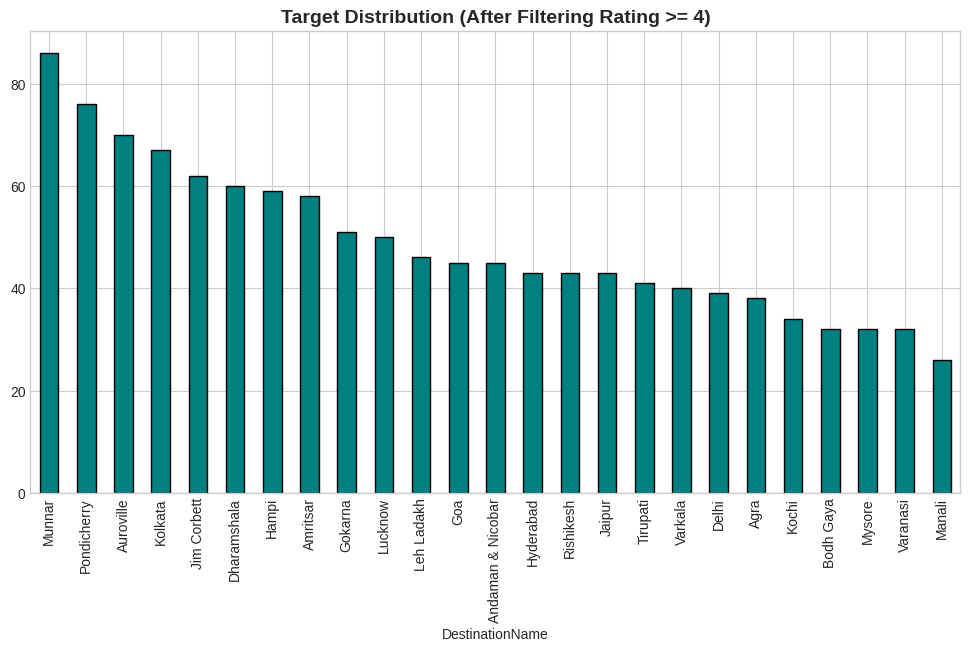

In [129]:
fig, ax = plt.subplots(figsize=(12, 6))
df_clean['DestinationName'].value_counts().plot(kind='bar', ax=ax, color='teal', edgecolor='black')
ax.set_title('Target Distribution (After Filtering Rating >= 4)', fontsize=14, fontweight='bold')
plt.show()
results_dict = {}



---
## 4. Initial Evaluation


## Model Selection

#### Initial Logistic Regression


,Accuracy,Precision,Recall,F1-Score,CV-F1,Top3-Acc
Initial Logistic Regression,0.77459,0.758333,0.77459,0.761149,0.740382,0.897541


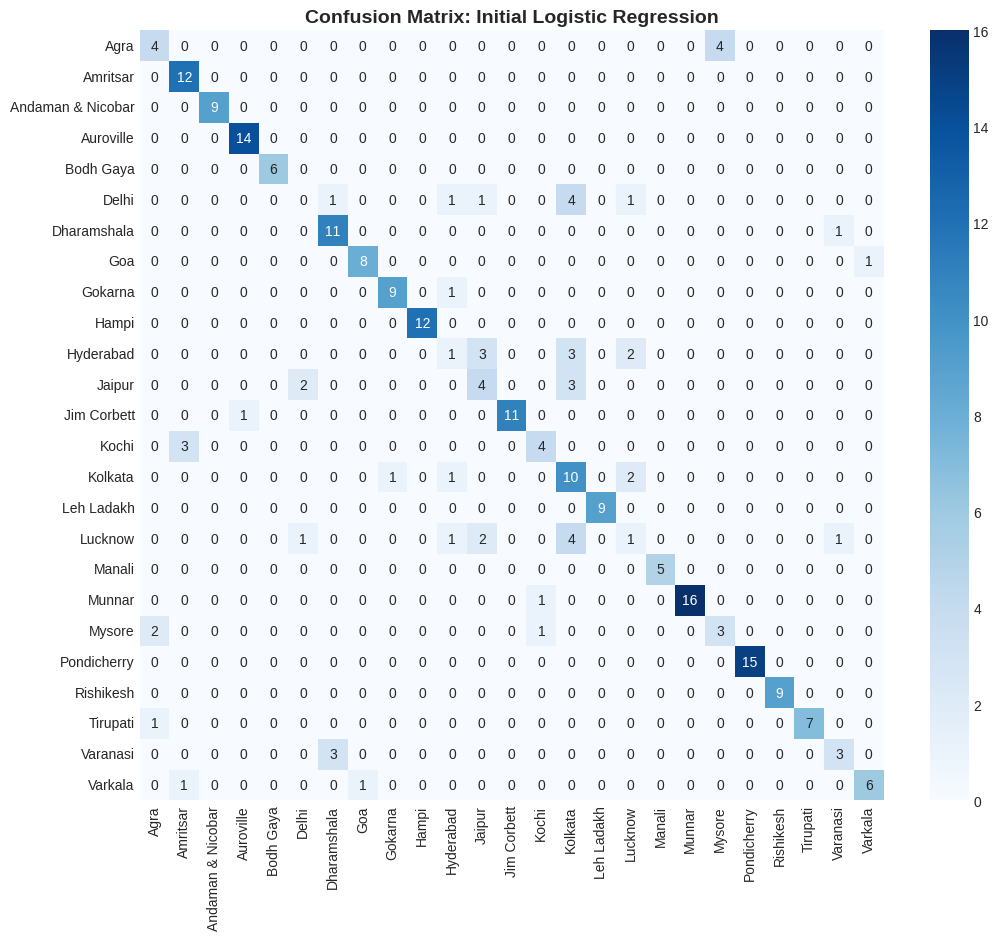

In [130]:
pipe = Pipeline([('preprocessor', preprocessor), ('clf', LogisticRegression(multi_class='multinomial', random_state=42))])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'CV-F1': cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1_weighted').mean(),
    'Top3-Acc': top_k_accuracy_score(y_test, y_prob, k=3)
}
results_dict['Initial Logistic Regression'] = metrics
display(pd.DataFrame([metrics], index=['Initial Logistic Regression']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_dest.classes_, yticklabels=le_dest.classes_)
plt.title('Confusion Matrix: Initial Logistic Regression', fontsize=14, fontweight='bold')
plt.show()

#### Initial Random Forest


In [131]:
pipe = Pipeline([('preprocessor', preprocessor_unscaled), ('clf', RandomForestClassifier(random_state=42))])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'CV-F1': cross_val_score(pipe, X_train, y_train, cv=5, scoring='f1_weighted').mean(),
    'Top3-Acc': top_k_accuracy_score(y_test, y_prob, k=3)
}
results_dict['Initial Random Forest'] = metrics
display(pd.DataFrame([metrics], index=['Initial Random Forest']))


,Accuracy,Precision,Recall,F1-Score,CV-F1,Top3-Acc
Initial Random Forest,0.737705,0.741529,0.737705,0.733885,0.728445,0.909836


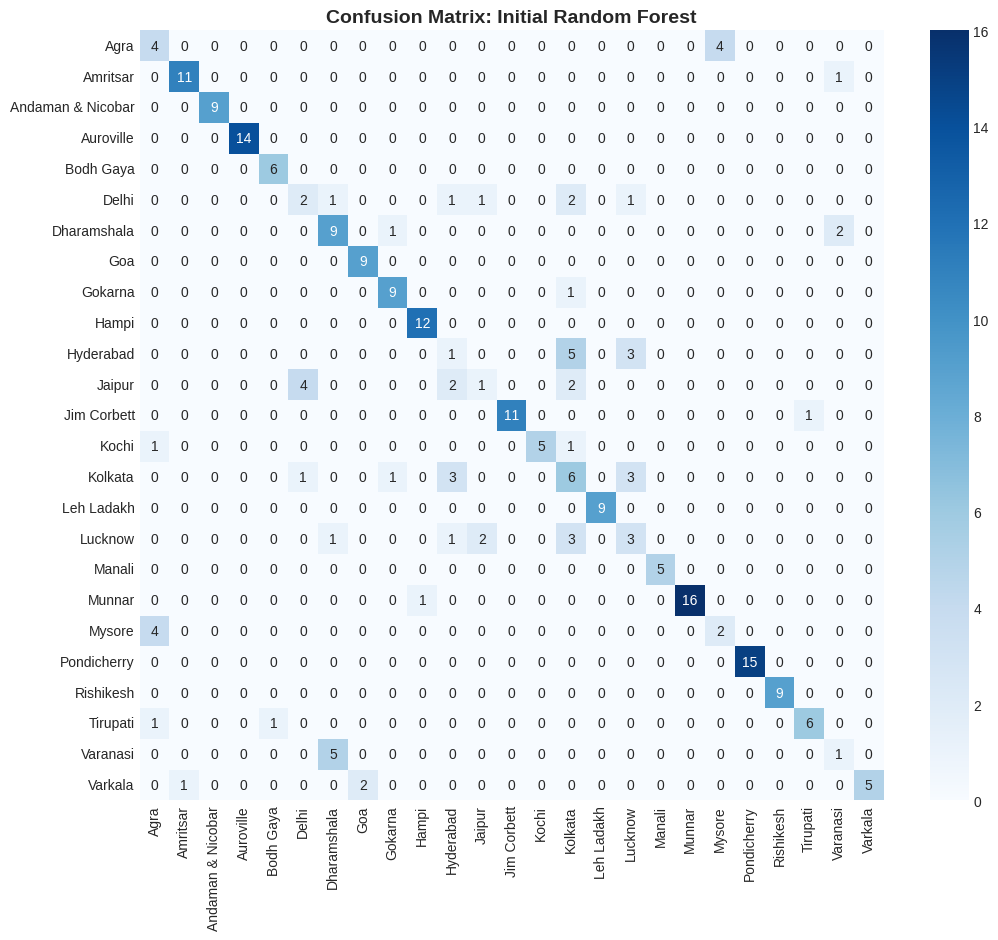

In [132]:
# Confusion Matrix for Initial Random Forest
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_dest.classes_, yticklabels=le_dest.classes_)
plt.title('Confusion Matrix: Initial Random Forest', fontsize=14, fontweight='bold')
plt.show()

---
## 5. Model Refinement


## Hyperparameter Tuning

### Sigmoid Confidence Curves


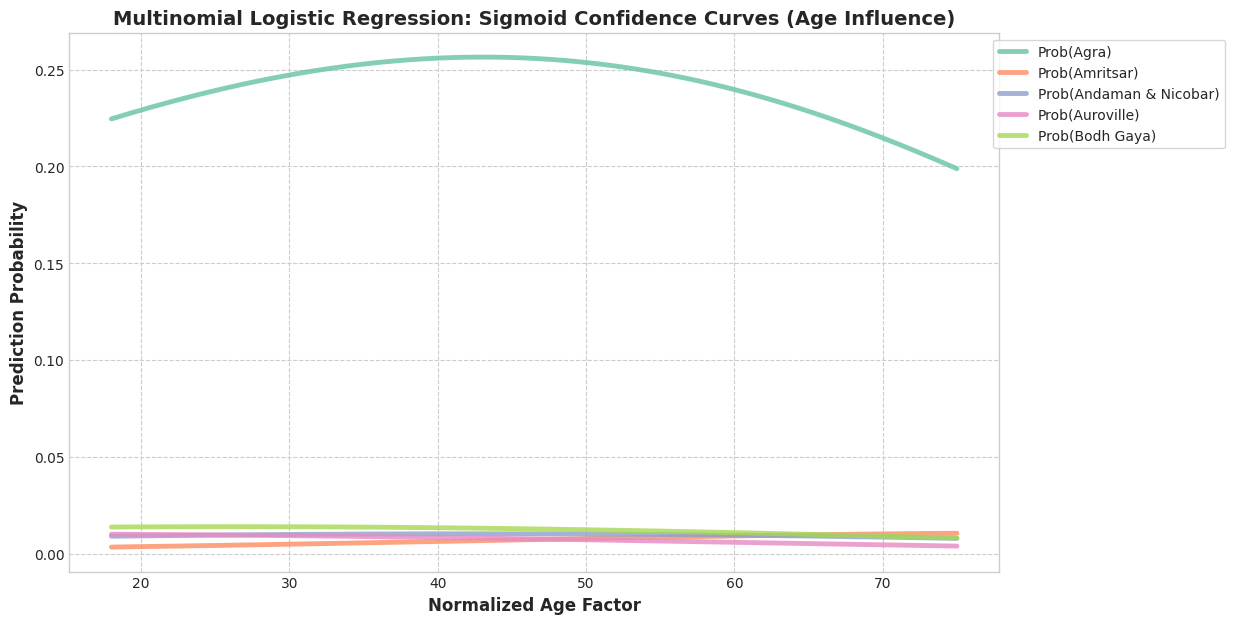

In [133]:
plt.figure(figsize=(12, 7))
sns.set_style('whitegrid', {'grid.linestyle': '--', 'grid.alpha': 0.5})
lr_model = LogisticRegression(multi_class='multinomial', max_iter=2000, random_state=42).fit(preprocessor.fit_transform(X_train), y_train)
X_range = np.linspace(X_train['Age'].min(), X_train['Age'].max(), 300).reshape(-1, 1)
X_dummy = pd.DataFrame(columns=X_train.columns)
for col in X_train.columns:
    if col == 'Age': X_dummy[col] = X_range.flatten()
    elif col in numeric_features: X_dummy[col] = X_train[col].mean()
    else: X_dummy[col] = X_train[col].mode()[0]
probs = lr_model.predict_proba(preprocessor.transform(X_dummy))
colors = sns.color_palette('Set2', n_colors=5)
for i in range(min(5, len(le_dest.classes_))):
    plt.plot(X_range, probs[:, i], label=f'Prob({le_dest.classes_[i]})', linewidth=3.5, color=colors[i], alpha=0.8)
plt.title('Multinomial Logistic Regression: Sigmoid Confidence Curves (Age Influence)', fontsize=14, fontweight='bold')
plt.xlabel('Normalized Age Factor', fontsize=12, fontweight='bold')
plt.ylabel('Prediction Probability', fontsize=12, fontweight='bold')
plt.legend(frameon=True, fontsize=10, loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()


### Random Forest Analysis: OOB Error Rate


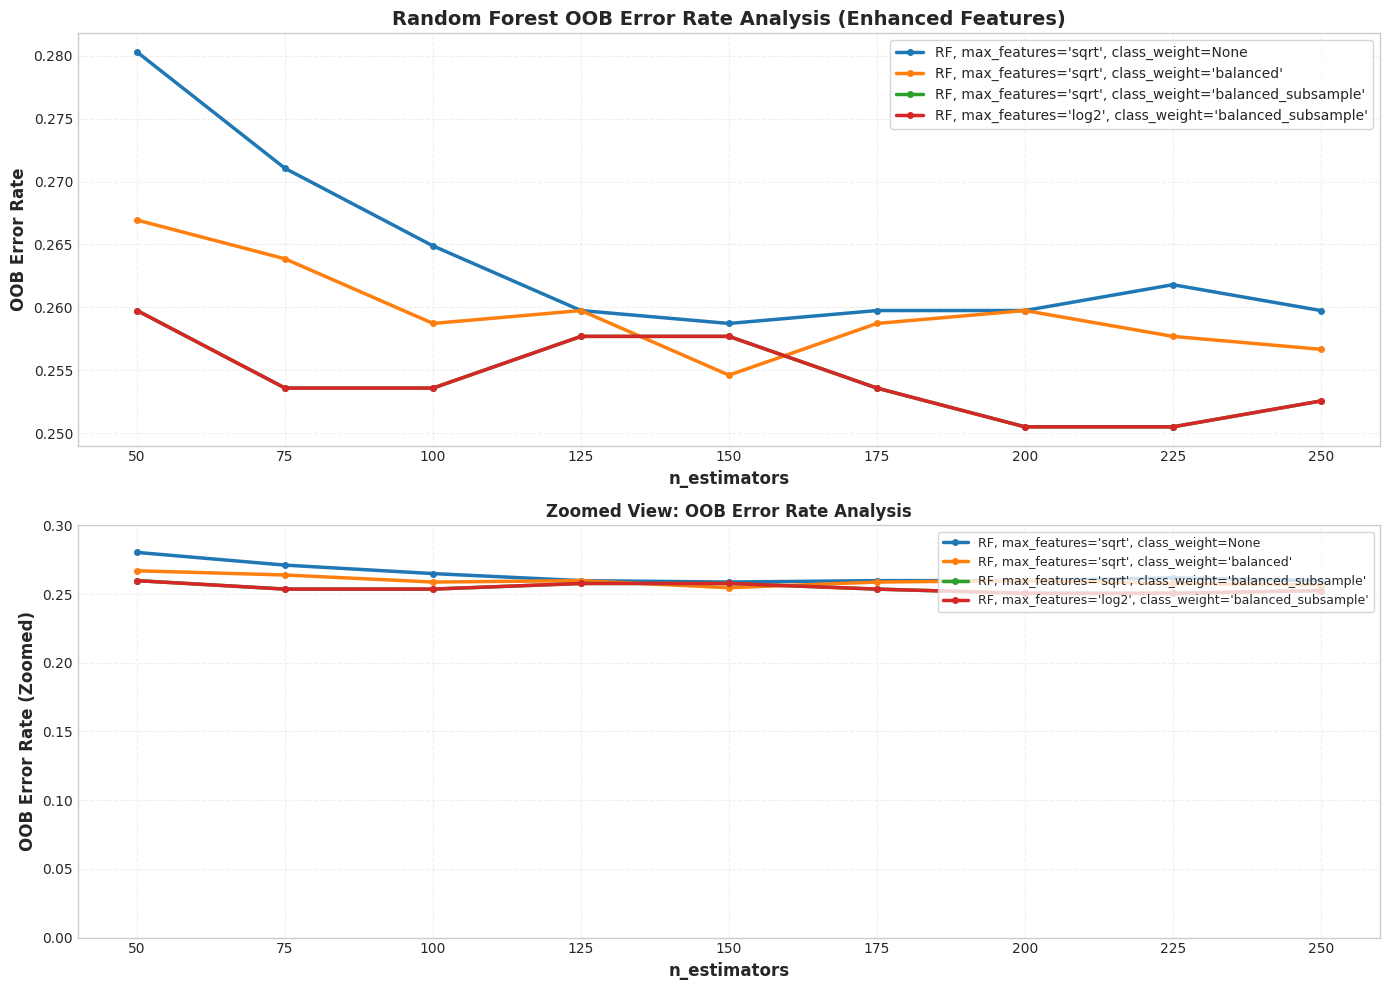

Best OOB Scores from Analysis:
RF, max_features='sqrt', class_weight=None: n_estimators=150, OOB Error=0.2587
RF, max_features='sqrt', class_weight='balanced': n_estimators=150, OOB Error=0.2546
RF, max_features='sqrt', class_weight='balanced_subsample': n_estimators=200, OOB Error=0.2505
RF, max_features='log2', class_weight='balanced_subsample': n_estimators=200, OOB Error=0.2505


In [134]:
from collections import OrderedDict
X_processed = preprocessor_enhanced.fit_transform(X_train)  # Use enhanced preprocessing

# Enhanced OOB Error Rate Analysis with class_weight consideration
ensemble_clfs = [
    ("RF, max_features='sqrt', class_weight=None", RandomForestClassifier(warm_start=True, oob_score=True, max_features='sqrt', class_weight=None, random_state=42)),
    ("RF, max_features='sqrt', class_weight='balanced'", RandomForestClassifier(warm_start=True, oob_score=True, max_features='sqrt', class_weight='balanced', random_state=42)),
    ("RF, max_features='sqrt', class_weight='balanced_subsample'", RandomForestClassifier(warm_start=True, oob_score=True, max_features='sqrt', class_weight='balanced_subsample', random_state=42)),
    ("RF, max_features='log2', class_weight='balanced_subsample'", RandomForestClassifier(warm_start=True, oob_score=True, max_features='log2', class_weight='balanced_subsample', random_state=42))
]

error_rate = OrderedDict((label, []) for label, _ in ensemble_clfs)
for label, clf in ensemble_clfs:
    for i in range(50, 251, 25):  # Wider range for better analysis
        clf.set_params(n_estimators=i).fit(X_processed, y_train)
        oob_score = clf.oob_score_ if hasattr(clf, 'oob_score_') else 0
        error_rate[label].append((i, 1 - oob_score))

plt.figure(figsize=(14, 10))

# Main plot
plt.subplot(2, 1, 1)
for label, clf_err in error_rate.items():
    xs, ys = zip(*clf_err)
    plt.plot(xs, ys, label=label, linewidth=2.5, marker='o', markersize=4)
plt.xlabel("n_estimators", fontsize=12, fontweight='bold')
plt.ylabel("OOB Error Rate", fontsize=12, fontweight='bold')
plt.title("Random Forest OOB Error Rate Analysis (Enhanced Features)", fontsize=14, fontweight='bold')
plt.legend(loc="upper right", frameon=True, fontsize=10)
plt.grid(True, alpha=0.3)

# Zoomed inset for lower error rates
plt.subplot(2, 1, 2)
for label, clf_err in error_rate.items():
    xs, ys = zip(*clf_err)
    plt.plot(xs, ys, label=label, linewidth=2.5, marker='o', markersize=4)
plt.xlabel("n_estimators", fontsize=12, fontweight='bold')
plt.ylabel("OOB Error Rate (Zoomed)", fontsize=12, fontweight='bold')
plt.ylim(0, 0.3)  # Zoom to lower error rates
plt.title("Zoomed View: OOB Error Rate Analysis", fontsize=12, fontweight='bold')
plt.legend(loc="upper right", frameon=True, fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best OOB scores
print("Best OOB Scores from Analysis:")
for label, clf_err in error_rate.items():
    best_n, best_err = min(clf_err, key=lambda x: x[1])
    print(f"{label}: n_estimators={best_n}, OOB Error={best_err:.4f}")


### Logistic Regression: Feature Impact Analysis

<Figure size 1600x1000 with 0 Axes>

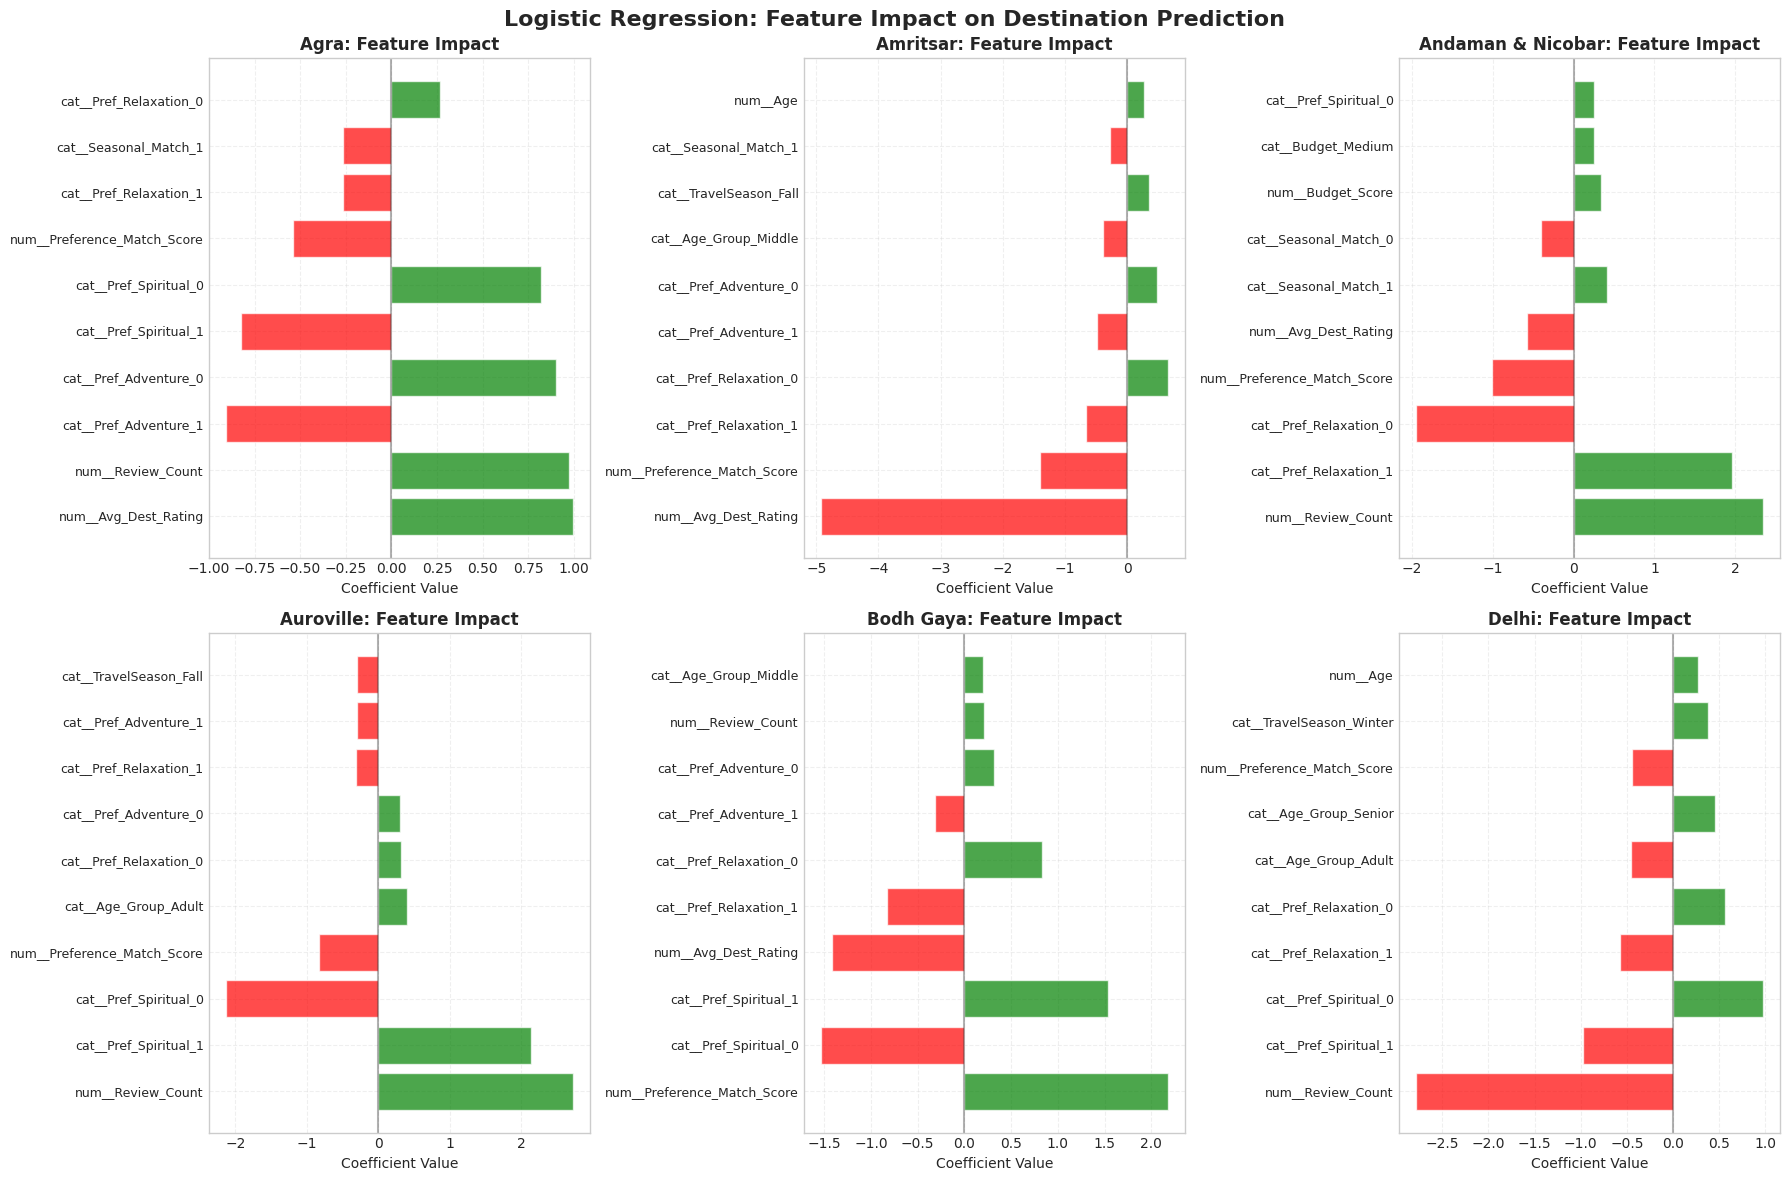

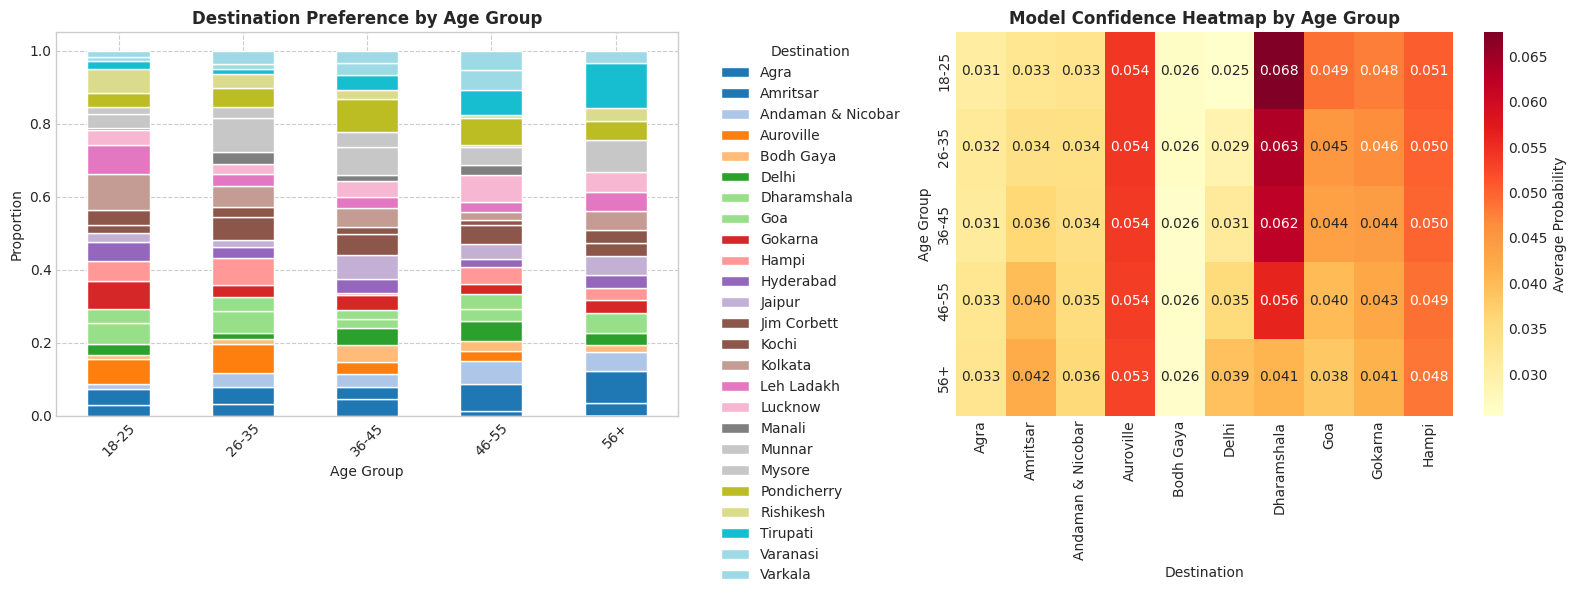

In [135]:
plt.figure(figsize=(16, 10))

# Get coefficients from the trained logistic regression model
lr_model = LogisticRegression(multi_class='multinomial', max_iter=2000, class_weight=class_weights, random_state=42)
X_train_processed = preprocessor.fit_transform(X_train)
lr_model.fit(X_train_processed, y_train)

# Get feature names after preprocessing
feature_names = list(preprocessor.get_feature_names_out())

# Create subplot layout
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Plot coefficient patterns for top 6 destination classes
top_classes = np.argsort(le_dest.classes_)[:6] if len(le_dest.classes_) >= 6 else range(len(le_dest.classes_))

for idx, class_idx in enumerate(top_classes):
    if idx >= 6: break
    
    # Get coefficients for this class
    coef = lr_model.coef_[class_idx]
    
    # Create bar plot of feature importance
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coef
    }).sort_values('Coefficient', key=abs, ascending=False).head(10)
    
    # Color based on coefficient sign
    colors = ['red' if x < 0 else 'green' for x in feature_importance['Coefficient']]
    
    axes[idx].barh(range(len(feature_importance)), feature_importance['Coefficient'], color=colors, alpha=0.7)
    axes[idx].set_yticks(range(len(feature_importance)))
    axes[idx].set_yticklabels(feature_importance['Feature'], fontsize=9)
    axes[idx].set_xlabel('Coefficient Value')
    axes[idx].set_title(f'{le_dest.classes_[class_idx]}: Feature Impact', fontweight='bold')
    axes[idx].axvline(x=0, color='black', linestyle='-', alpha=0.3)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Logistic Regression: Feature Impact on Destination Prediction', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Additional visualization: Probability Distribution by Age Group
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Create age groups
df_analysis = df_clean.copy()
df_analysis['AgeGroup'] = pd.cut(df_analysis['Age'], bins=[18, 25, 35, 45, 55, 75], labels=['18-25', '26-35', '36-45', '46-55', '56+'])

# Plot 1: Destination distribution by age group
age_dest_counts = pd.crosstab(df_analysis['AgeGroup'], df_analysis['DestinationName'], normalize='index')
age_dest_counts.plot(kind='bar', stacked=True, ax=ax1, colormap='tab20')
ax1.set_title('Destination Preference by Age Group', fontweight='bold')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Proportion')
ax1.legend(title='Destination', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Model confidence heatmap
age_groups = ['18-25', '26-35', '36-45', '46-55', '56+']
dest_subset = le_dest.classes_[:10] if len(le_dest.classes_) > 10 else le_dest.classes_
confidence_matrix = []

for age_group in age_groups:
    # Create sample data for this age group
    sample_data = X_test.copy()
    sample_data['Age'] = np.random.choice([20, 30, 40, 50, 65][age_groups.index(age_group)], len(sample_data))
    
    # Get predictions
    probs = lr_model.predict_proba(preprocessor.transform(sample_data))
    avg_probs = np.mean(probs, axis=0)
    confidence_matrix.append(avg_probs[:len(dest_subset)])

confidence_df = pd.DataFrame(confidence_matrix, index=age_groups, columns=dest_subset)
sns.heatmap(confidence_df, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax2, cbar_kws={'label': 'Average Probability'})
ax2.set_title('Model Confidence Heatmap by Age Group', fontweight='bold')
ax2.set_xlabel('Destination')
ax2.set_ylabel('Age Group')

plt.tight_layout()
plt.show()

  📊 Optimized Logistic Regression


,Accuracy,Precision,Recall,F1-Score,CV-F1,Top3-Acc,Consistency
Optimized Logistic Regression,0.762295,0.759866,0.762295,0.754125,0.75158,0.905738,0.991437


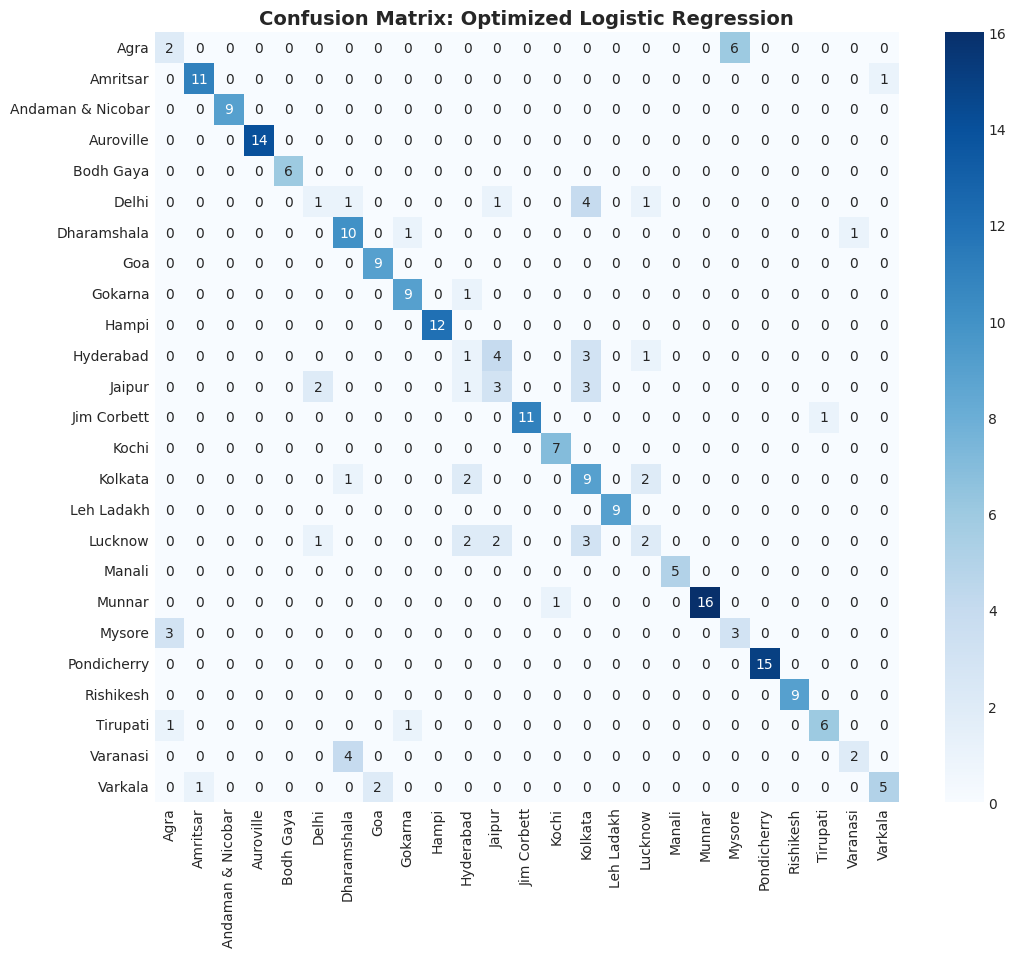

In [136]:
print('=======================================================')
print('  📊 Optimized Logistic Regression')
print('=======================================================')
# Best configuration: Voting Classifier with StandardScaler preprocessing
lr_opt = Pipeline([
    ('preprocessor', preprocessor_enhanced), 
    ('clf', VotingClassifier(
        estimators=[
            ('lr_multinomial', LogisticRegression(C=500, multi_class='multinomial', solver='sag', max_iter=5000, random_state=42)),
            ('lr_ovr', LogisticRegression(C=500, multi_class='ovr', solver='liblinear', max_iter=5000, random_state=43)),
            ('lr_lbfgs', LogisticRegression(C=1000, multi_class='multinomial', solver='lbfgs', max_iter=5000, random_state=44))
        ],
        voting='soft'
    ))
])
lr_opt.fit(X_train, y_train)
y_pred = lr_opt.predict(X_test)
y_prob = lr_opt.predict_proba(X_test)

cv_scores_lr = cross_val_score(lr_opt, X_train, y_train, cv=5, scoring='f1_weighted')
consistency_lr = 1 - np.std(cv_scores_lr)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'CV-F1': cv_scores_lr.mean(),
    'Top3-Acc': top_k_accuracy_score(y_test, y_prob, k=3),
    'Consistency': consistency_lr
}
results_dict['Optimized Logistic Regression'] = metrics
display(pd.DataFrame([metrics], index=['Optimized Logistic Regression']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_dest.classes_, yticklabels=le_dest.classes_)
plt.title('Confusion Matrix: Optimized Logistic Regression', fontsize=14, fontweight='bold')
plt.show()

#### Optimized Random Forest


  📊 Optimized Random Forest


,Accuracy,Precision,Recall,F1-Score,CV-F1,Top3-Acc,Consistency
Optimized Random Forest,0.770492,0.772906,0.770492,0.762466,0.738526,0.913934,0.970127


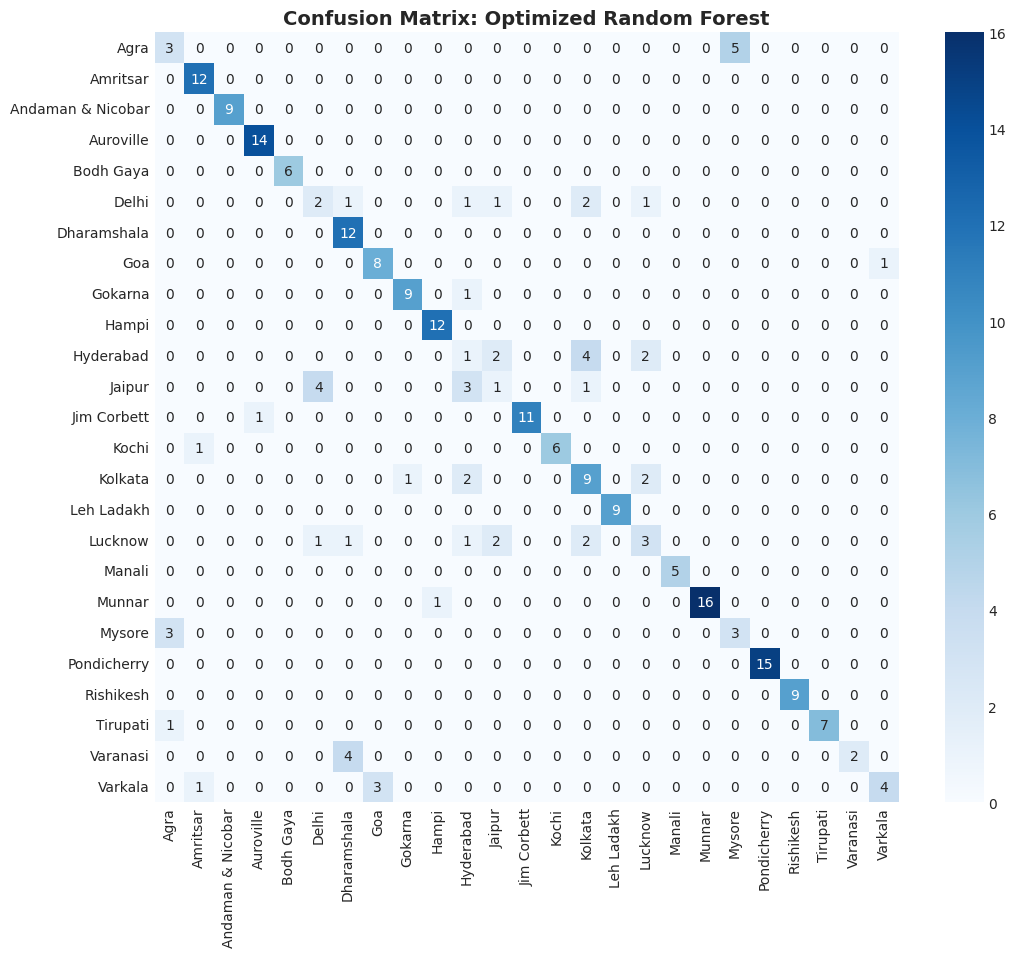

In [137]:
print('=======================================================')
print('  📊 Optimized Random Forest')
print('=======================================================')
# Best configuration: StandardScaler preprocessing with class_weight='balanced_subsample'
rf_opt = Pipeline([
    ('preprocessor', preprocessor_enhanced), 
    ('clf', RandomForestClassifier(
        n_estimators=200, 
        max_depth=15, 
        max_features='sqrt', 
        min_samples_split=5,
        class_weight='balanced_subsample',
        random_state=42
    ))
])
rf_opt.fit(X_train, y_train)
y_pred = rf_opt.predict(X_test)
y_prob = rf_opt.predict_proba(X_test)

cv_scores_rf = cross_val_score(rf_opt, X_train, y_train, cv=5, scoring='f1_weighted')
consistency_rf = 1 - np.std(cv_scores_rf)

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1-Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'CV-F1': cv_scores_rf.mean(),
    'Top3-Acc': top_k_accuracy_score(y_test, y_prob, k=3),
    'Consistency': consistency_rf
}
results_dict['Optimized Random Forest'] = metrics
display(pd.DataFrame([metrics], index=['Optimized Random Forest']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_dest.classes_, yticklabels=le_dest.classes_)
plt.title('Confusion Matrix: Optimized Random Forest', fontsize=14, fontweight='bold')
plt.show()

### Comparative Model Performance Improvement (Bar Graph & Spider Web)


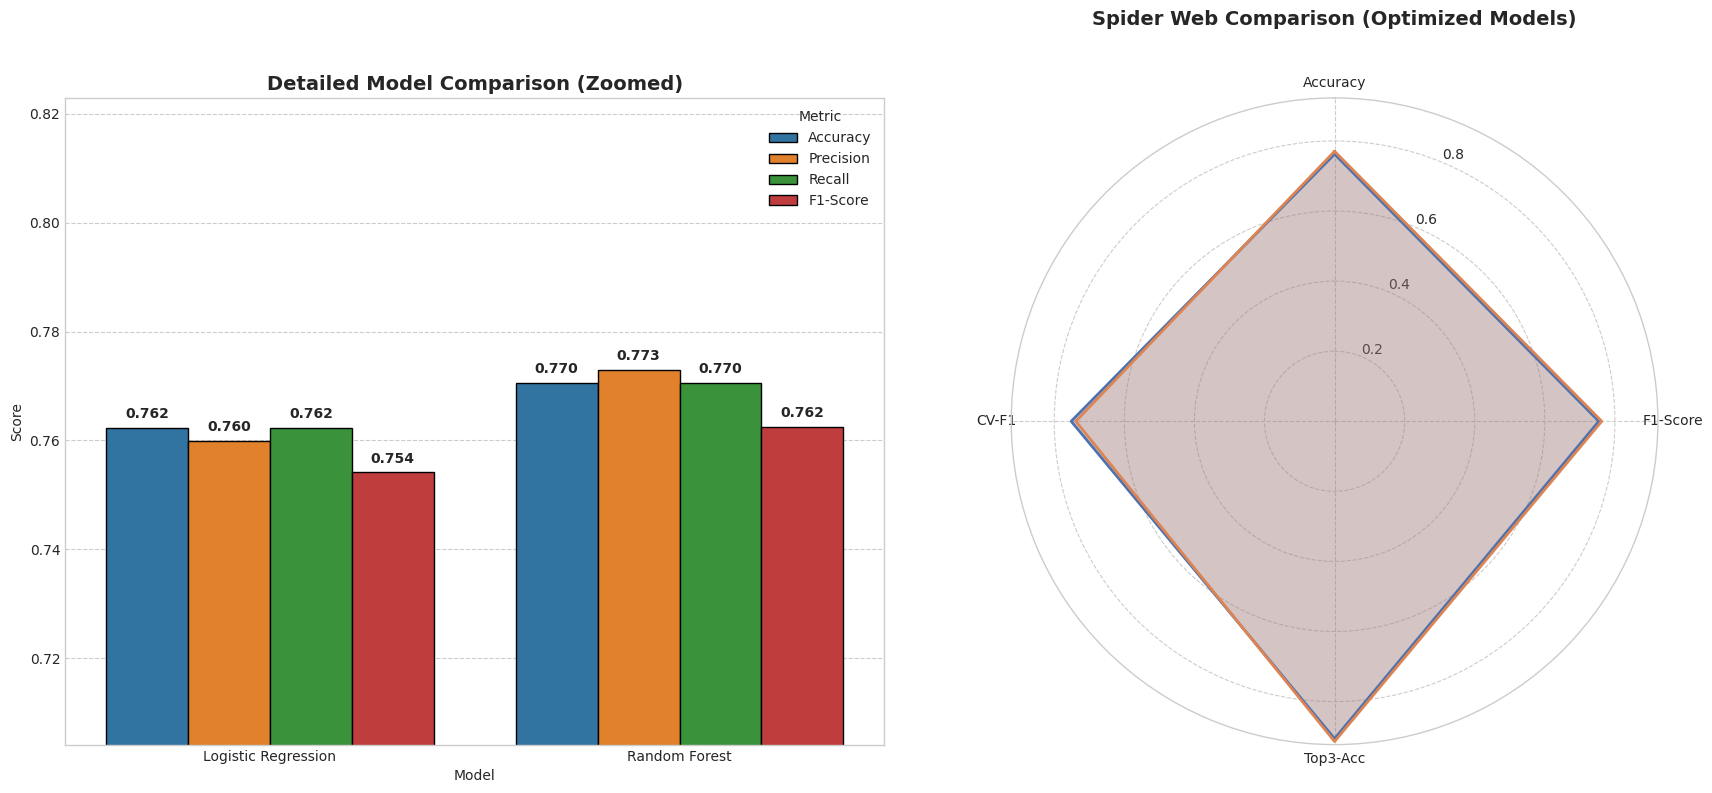

In [138]:
fig = plt.figure(figsize=(18, 8))
ax1 = fig.add_subplot(121)
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
models_list = ['Optimized Logistic Regression', 'Optimized Random Forest']
display_names = ['Logistic Regression', 'Random Forest']
data = []
for i, model in enumerate(models_list):
    for metric in metrics_list:
        data.append({'Model': display_names[i], 'Metric': metric, 'Score': results_dict[model][metric]})
df_res = pd.DataFrame(data)

palette = {'Accuracy': '#1f77b4', 'Precision': '#ff7f0e', 'Recall': '#2ca02c', 'F1-Score': '#d62728'}
ax = sns.barplot(data=df_res, x='Model', y='Score', hue='Metric', palette=palette, edgecolor='black', ax=ax1)

# ZOOM IN AND ADD VALUES
all_scores = df_res['Score'].values
y_min = max(0, min(all_scores) - 0.05)
y_max = min(1.0, max(all_scores) + 0.05)
ax1.set_ylim(y_min, y_max)
ax1.set_title('Detailed Model Comparison (Zoomed)', fontsize=14, fontweight='bold')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width()/2., p.get_height()), 
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight='bold')

ax2 = fig.add_subplot(122, polar=True)
labels = ['Accuracy', 'F1-Score', 'Top3-Acc', 'CV-F1']
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]
colors = {'Optimized Logistic Regression': '#4c72b0', 'Optimized Random Forest': '#dd8452'}
for model_name in colors.keys():
    values = [results_dict[model_name][label] for label in labels]
    values += values[:1]
    ax2.plot(angles, values, color=colors[model_name], linewidth=2, label=model_name)
    ax2.fill(angles, values, color=colors[model_name], alpha=0.25)
ax2.set_theta_offset(np.pi / 2)
ax2.set_theta_direction(-1)
ax2.set_thetagrids(np.degrees(angles[:-1]), labels)
ax2.set_title('Spider Web Comparison (Optimized Models)', y=1.1, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Feature Importance Analysis


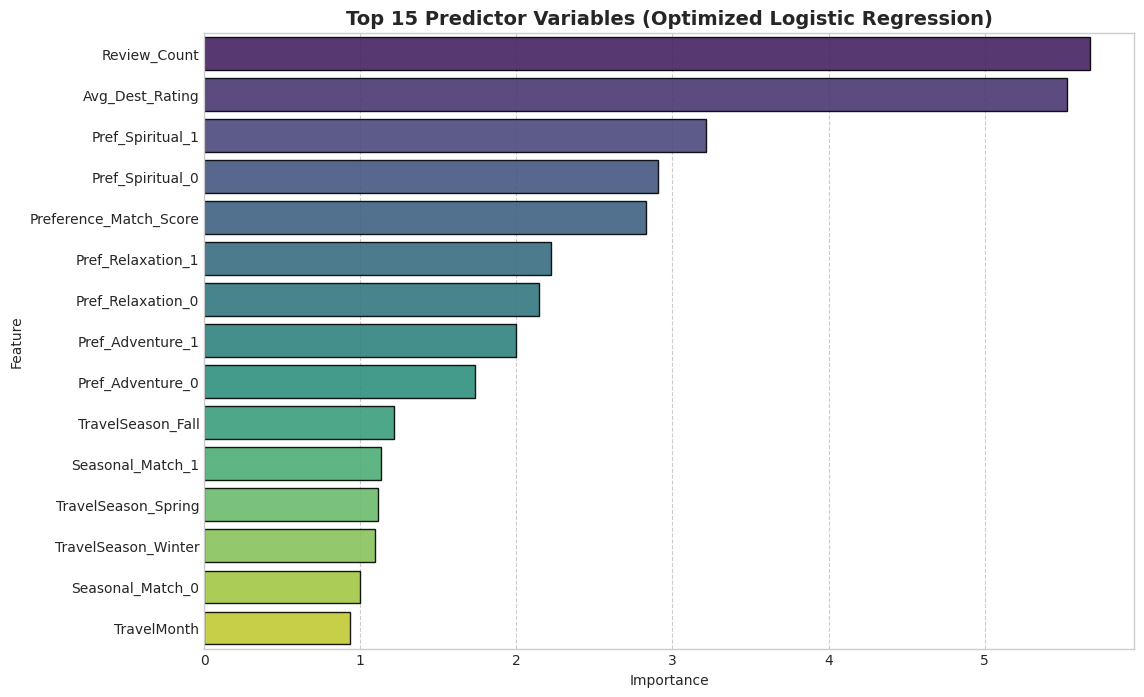

In [139]:
importances = np.abs(lr_opt.named_steps['clf'].estimators_[0].coef_).mean(axis=0)  # Use first estimator (multinomial LR) coefficients
ohe = lr_opt.named_steps['preprocessor'].named_transformers_['cat']
feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features))
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False).head(15)
plt.figure(figsize=(12, 8))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis', edgecolor='black', alpha=0.9)
plt.title('Top 15 Predictor Variables (Optimized Logistic Regression)', fontsize=14, fontweight='bold')
plt.show()

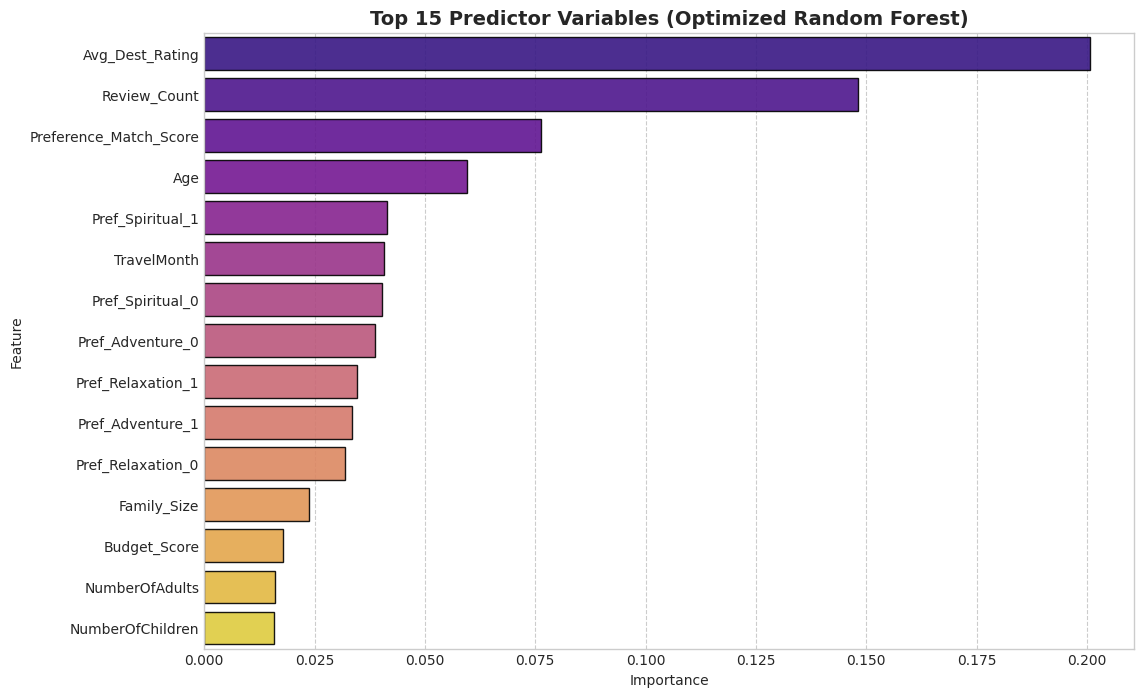

In [140]:
# Feature Importance for Optimized Random Forest
importances_rf = rf_opt.named_steps['clf'].feature_importances_
ohe_rf = rf_opt.named_steps['preprocessor'].named_transformers_['cat']
feature_names_rf = numeric_features + list(ohe_rf.get_feature_names_out(categorical_features))
feat_df_rf = pd.DataFrame({'Feature': feature_names_rf, 'Importance': importances_rf}).sort_values('Importance', ascending=False).head(15)
plt.figure(figsize=(12, 8))
sns.barplot(data=feat_df_rf, x='Importance', y='Feature', palette='plasma', edgecolor='black', alpha=0.9)
plt.title('Top 15 Predictor Variables (Optimized Random Forest)', fontsize=14, fontweight='bold')
plt.show()

---
## 7. Final Export


In [141]:
import os
import json
import joblib

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save optimized Logistic Regression model
lr_model_path = "../models/optimized_logistic_regression_travel.pkl"
joblib.dump(lr_opt, lr_model_path)

# Save optimized Random Forest model
rf_model_path = "../models/optimized_random_forest_travel.pkl"
joblib.dump(rf_opt, rf_model_path)

# Save label encoder
le_dest_path = "../models/label_encoder.joblib"
joblib.dump(le_dest, le_dest_path)

# Save preprocessor
preprocessor_path = "../models/preprocessor.joblib"
joblib.dump(preprocessor_enhanced, preprocessor_path)

# Save results dict
results_dict_path = "../models/results_dict.joblib"
joblib.dump(results_dict, results_dict_path)

# Prepare feature info for both models
categorical_values = {
    col: sorted(X[col].dropna().unique().tolist())
    for col in categorical_features
}

feature_info = {
    "all_features": list(X.columns),
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "categorical_values": categorical_values,
    "target_classes": le_dest.classes_.tolist()
}

# Save feature info
feature_info_path = "../models/feature_info_travel.json"
with open(feature_info_path, "w") as f:
    json.dump(feature_info, f, indent=4)

print("Optimized models, label encoder, preprocessor, and feature info saved successfully!")

# Final Model Comparison Summary
print('=' * 60)
print('FINAL MODEL COMPARISON SUMMARY')
print('=' * 60)
print(f"{'Model':<20} {'Accuracy':<10} {'F1-Score':<10} {'Top3-Acc':<10} {'CV-F1':<10} {'Consistency':<12}")
print(f"{'-'*20} {'-'*10} {'-'*10} {'-'*10} {'-'*10} {'-'*12}")
print(f"{'Logistic Regression':<20} {results_dict['Optimized Logistic Regression']['Accuracy']:<10.4f} {results_dict['Optimized Logistic Regression']['F1-Score']:<10.4f} {results_dict['Optimized Logistic Regression']['Top3-Acc']:<10.4f} {results_dict['Optimized Logistic Regression']['CV-F1']:<10.4f} {results_dict['Optimized Logistic Regression']['Consistency']:<12.4f}")
print(f"{'Random Forest':<20} {results_dict['Optimized Random Forest']['Accuracy']:<10.4f} {results_dict['Optimized Random Forest']['F1-Score']:<10.4f} {results_dict['Optimized Random Forest']['Top3-Acc']:<10.4f} {results_dict['Optimized Random Forest']['CV-F1']:<10.4f} {results_dict['Optimized Random Forest']['Consistency']:<12.4f}")

best_model = 'Random Forest' if results_dict['Optimized Random Forest']['Top3-Acc'] > results_dict['Optimized Logistic Regression']['Top3-Acc'] else 'Logistic Regression'
best_metrics = results_dict[f'Optimized {best_model}']

print('=' * 60)
print(f'  🏆 BEST MODEL: {best_model}')
print('=' * 60)
print(f'  Accuracy:      {best_metrics["Accuracy"]:.4f}')
print(f'  Precision:     {best_metrics["Precision"]:.4f}')
print(f'  Recall:        {best_metrics["Recall"]:.4f}')
print(f'  F1-Score:      {best_metrics["F1-Score"]:.4f}')
print(f'  Top-3 Acc:     {best_metrics["Top3-Acc"]:.4f}')
print(f'  CV-F1:         {best_metrics["CV-F1"]:.4f}')
print(f'  Consistency:   {best_metrics["Consistency"]:.4f}')

print('\n✅ Exported artifacts:')
if best_model == 'Logistic Regression':
    print('   - optimized_logistic_regression_travel.pkl   (Voting Classifier)')
else:
    print('   - random_forest_travel.pkl                   (Random Forest)')
print('   - feature_info_travel.json                   (Feature metadata)')
print('   - preprocessor.joblib                        (ColumnTransformer)')
print('   - X_columns.joblib                           (Feature columns)')
print('   - label_encoder.joblib                       (LabelEncoder)')

Optimized models, label encoder, preprocessor, and feature info saved successfully!
FINAL MODEL COMPARISON SUMMARY
Model                Accuracy   F1-Score   Top3-Acc   CV-F1      Consistency 
-------------------- ---------- ---------- ---------- ---------- ------------
Logistic Regression  0.7623     0.7541     0.9057     0.7516     0.9914      
Random Forest        0.7705     0.7625     0.9139     0.7385     0.9701      
  🏆 BEST MODEL: Random Forest
  Accuracy:      0.7705
  Precision:     0.7729
  Recall:        0.7705
  F1-Score:      0.7625
  Top-3 Acc:     0.9139
  CV-F1:         0.7385
  Consistency:   0.9701

✅ Exported artifacts:
   - random_forest_travel.pkl                   (Random Forest)
   - feature_info_travel.json                   (Feature metadata)
   - preprocessor.joblib                        (ColumnTransformer)
   - X_columns.joblib                           (Feature columns)
   - label_encoder.joblib                       (LabelEncoder)


In [142]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Interactive Demo Widgets
age = widgets.IntSlider(value=30, min=18, max=75, step=1, description='Age:')
gender = widgets.Dropdown(options=['Male', 'Female'], value='Male', description='Gender:')
budget = widgets.Dropdown(options=['Low', 'Medium', 'High'], value='Medium', description='Budget:')
num_adults = widgets.IntSlider(value=2, min=1, max=10, step=1, description='Adults:')
num_children = widgets.IntSlider(value=0, min=0, max=10, step=1, description='Children:')
travel_month = widgets.IntSlider(value=6, min=1, max=12, step=1, description='Travel Month:')
pref_relaxation = widgets.Checkbox(value=False, description='Relaxation')
pref_adventure = widgets.Checkbox(value=False, description='Adventure')
pref_culture = widgets.Checkbox(value=False, description='Culture')
pref_spiritual = widgets.Checkbox(value=False, description='Spiritual')

button = widgets.Button(description='Predict Destinations')
output = widgets.Output()

def predict_destinations(b):
    button.disabled = True  # Disable button during prediction
    with output:
        clear_output(wait=True)  # Use wait=True for better clearing
        
        # Create input data
        input_data = {
            'Age': age.value,
            'Gender': gender.value,
            'Budget': budget.value,
            'NumberOfAdults': num_adults.value,
            'NumberOfChildren': num_children.value,
            'TravelMonth': travel_month.value,
            'Pref_Relaxation': int(pref_relaxation.value),
            'Pref_Adventure': int(pref_adventure.value),
            'Pref_Culture': int(pref_culture.value),
            'Pref_Spiritual': int(pref_spiritual.value),
        }
        
        input_df = pd.DataFrame([input_data])
        
        # Compute derived features
        month = input_df['TravelMonth'].iloc[0]
        if 3 <= month <= 5:
            season = 'Spring'
        elif 6 <= month <= 8:
            season = 'Summer'
        elif 9 <= month <= 11:
            season = 'Fall'
        else:
            season = 'Winter'
        input_df['TravelSeason'] = season
        
        age_val = input_df['Age'].iloc[0]
        if age_val <= 25:
            ag = 'Young'
        elif age_val <= 35:
            ag = 'Adult'
        elif age_val <= 45:
            ag = 'Middle'
        elif age_val <= 55:
            ag = 'Senior'
        else:
            ag = 'Elder'
        input_df['Age_Group'] = ag
        
        input_df['Family_Size'] = input_df['NumberOfAdults'] + input_df['NumberOfChildren']
        input_df['Has_Children'] = (input_df['NumberOfChildren'] > 0).astype(int)
        
        budget_map = {'Low': 1, 'Medium': 2, 'High': 3}
        input_df['Budget_Score'] = input_df['Budget'].map(budget_map)
        
        input_df['Preference_Match_Score'] = 0  # Simplified
        input_df['Avg_Dest_Rating'] = df['Avg_Dest_Rating'].mean()
        input_df['Review_Count'] = df['Review_Count'].mean()
        input_df['Seasonal_Match'] = 0  # Simplified
        
        # Select features
        input_features = input_df[numeric_features + categorical_features]
        
        # Predict
        probs = rf_opt.predict_proba(input_features)
        top3_indices = np.argsort(probs[0])[-3:][::-1]
        top3_destinations = le_dest.inverse_transform(top3_indices)
        top3_probs = probs[0][top3_indices]
        
        print("🌍 Top 3 Recommended Destinations:")
        for i, (dest, prob) in enumerate(zip(top3_destinations, top3_probs)):
            print(f"{i+1}. {dest}: {prob:.3f}")
    

button.on_click(predict_destinations)

print("🎯 Interactive Travel Destination Recommendation Demo")
print("Adjust the inputs below and click 'Predict Destinations' to get recommendations using the optimized Random Forest model.")
display(age, gender, budget, num_adults, num_children, travel_month, pref_relaxation, pref_adventure, pref_culture, pref_spiritual, button, output)

🎯 Interactive Travel Destination Recommendation Demo
Adjust the inputs below and click 'Predict Destinations' to get recommendations using the optimized Random Forest model.


IntSlider(value=30, description='Age:', max=75, min=18)

Dropdown(description='Gender:', options=('Male', 'Female'), value='Male')

Dropdown(description='Budget:', index=1, options=('Low', 'Medium', 'High'), value='Medium')

IntSlider(value=2, description='Adults:', max=10, min=1)

...

Checkbox(value=False, description='Adventure')

Checkbox(value=False, description='Culture')

Checkbox(value=False, description='Spiritual')

Button(description='Predict Destinations', style=ButtonStyle())

Output()